In [1]:
from reflect.data.loader import EnvDataLoader
from reflect.data.noise import NormalNoise
from reflect.components.transformer_world_model import WorldModel, WorldModelTrainingParams
from reflect.components.transformer_world_model.world_model_actor import TransformerWorldModelActor
from reflect.utils import CSVLogger
from torchvision.transforms import Resize, Compose
from reflect.components.models import Actor
from reflect.components.rssm_world_model.models import DenseModel
from reflect.components.transformer_world_model.transformer import PytfexTransformer
from reflect.utils import create_z_dist
from reflect.components.trainers.value.value_trainer import ValueGradTrainer
from reflect.components.trainers.value.critic import ValueCritic
from reflect.utils import CSVLogger

from livelossplot import PlotLosses
from torchvision.transforms import Resize, Compose
import gymnasium as gym


import gymnasium as gym
import matplotlib.pyplot as plt
import torch
import os
import click
import numpy as np
import pygame
import time
import torch
from tqdm import tqdm

/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
env = gym.make('Pendulum-v1', render_mode='rgb_array')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
device='cpu'


In [3]:
a_size=env.action_space.shape[0]

t_dim=4
num_cat=32
latent_dim=32

dynamic_model = PytfexTransformer(
    num_ts=t_dim-1,
    num_cat=num_cat,
    latent_dim=latent_dim,
    hdn_dim=256,
    dropout=0.0,
    num_heads=4,
    action_size=env.action_space.shape[0],
    num_layers=2,
).to(device)

In [4]:
encoder = DenseModel(
    depth=1,
    input_dim=env.observation_space.shape[0],
    hidden_dim=256,
    output_dim=32 * 32,
)

decoder = DenseModel(
    depth=1,
    input_dim=32 * 32,
    hidden_dim=256,
    output_dim=env.observation_space.shape[0],
)

In [5]:
params = WorldModelTrainingParams(
    reg_coeff=0,
    recon_coeff=1.0,
    dynamic_coeff=1.0,
    consistency_coeff=0.0,
    reward_coeff=10.0,
    done_coeff=50.0,
)

world_model = WorldModel(
    dynamic_model=dynamic_model,
    encoder=encoder,
    decoder=decoder,
    num_cat=num_cat,
    num_latent=latent_dim,
    params=params
).to(device)

world_model.dynamic_model.mask = world_model.dynamic_model.mask.to(device)

In [6]:
input_dim=num_cat*latent_dim

actor = Actor(
    input_dim=input_dim,
    output_dim=env.action_space.shape[0],
    bound=env.action_space.high,
).to(device)

critic = ValueCritic(
    state_dim=input_dim,
).to(device)

trainer = ValueGradTrainer(
    actor=actor,
    critic=critic,
    actor_lr=8e-05,
    critic_lr=8e-05,
    grad_clip=100.0
)
trainer.to(device)

In [7]:

world_model_actor = TransformerWorldModelActor(
    world_model=world_model,
    actor=actor
)

env_data_loader = EnvDataLoader(
    num_time_steps=t_dim,
    rollout_length=200,
    num_runs=1000,
    noise_size=0.3,
    state_shape=(state_dim,),
    policy=world_model_actor,
    env=env,
    use_imgs_as_states=False,
)


In [8]:
for _ in tqdm(range(10)):
    env_data_loader.perform_rollout()

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:41<00:00,  4.14s/it]


In [9]:

from livelossplot import PlotLosses

# plot_losses = PlotLosses(
#   groups={
#     'flow_loss': ['flow_loss'],
#     'rel_err': ['rel_err'],
#     'value_loss': ['value_loss'],
#     'value_grad_norm': ['value_grad_norm'],
#     'actor_loss': ['actor_loss'],
#     'actor_grad_norm': ['actor_grad_norm'],
#     'reward': ['reward'],
#     'imagined_reward': ['imagined_reward'],
#   },
# )

plot_losses = PlotLosses(
  groups={
    'recon_loss': ['recon_loss'],
    'reg_loss': ['reg_loss'],
    'consistency_loss': ['consistency_loss'],
    'dynamic_loss': ['dynamic_loss'],
    'reward_loss': ['reward_loss'],
    'done_loss': ['done_loss'],

    'value_loss': ['value_loss'],
    'value_grad_norm': ['value_grad_norm'],
    'actor_loss': ['actor_loss'],
    'actor_grad_norm': ['actor_grad_norm'],
    'reward': ['reward'],
    'imagined_reward': ['imagined_reward'],
  }
)

In [10]:
def test_actor(actor, env, render=False):
    o, *_ = env.reset()
    total_reward = 0
    images = []
    for _ in range(1000):
        o = torch.tensor(o)[None, None]
        a, *_ = world_model_actor(o)
        o, r, d, *_ = env.step(a.detach()[0])
        if render:
            images.append(env.render())
        total_reward += r
        if d:
            break
    if render:
        return total_reward, images
    else:
        return total_reward

test_actor(actor, env)


tensor(-6303.8174)

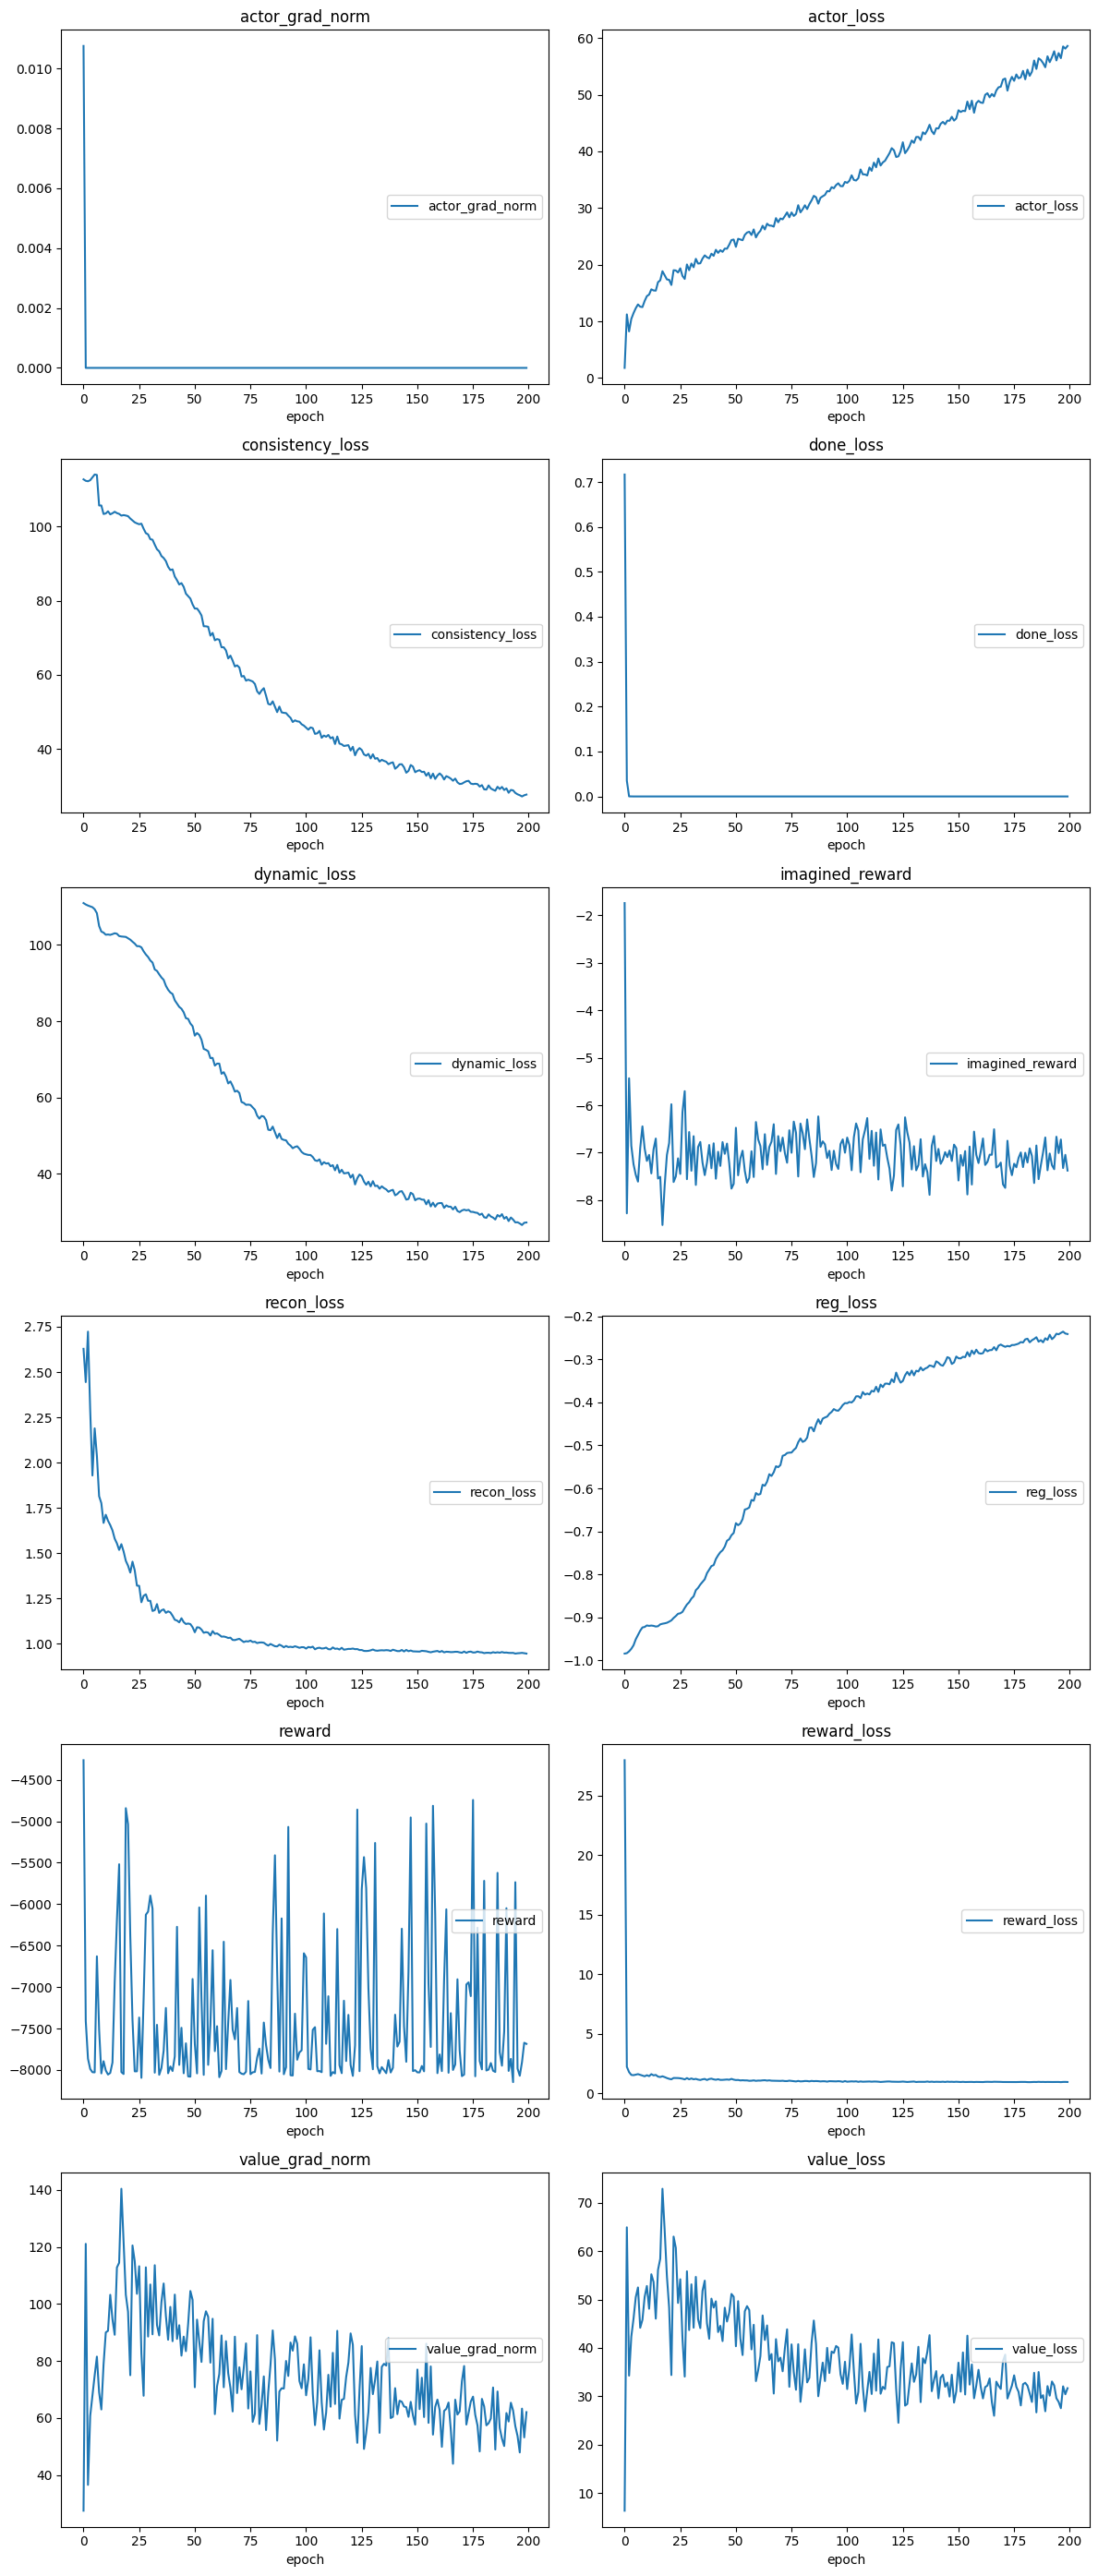

actor_grad_norm
	actor_grad_norm  	 (min:    0.000, max:    0.011, cur:    0.000)
actor_loss
	actor_loss       	 (min:    1.789, max:   58.598, cur:   58.598)
consistency_loss
	consistency_loss 	 (min:   27.218, max:  114.004, cur:   27.729)
done_loss
	done_loss        	 (min:    0.000, max:    0.717, cur:    0.000)
dynamic_loss
	dynamic_loss     	 (min:   26.623, max:  110.964, cur:   27.289)
imagined_reward
	imagined_reward  	 (min:   -8.524, max:   -1.742, cur:   -7.377)
recon_loss
	recon_loss       	 (min:    0.946, max:    2.723, cur:    0.946)
reg_loss
	reg_loss         	 (min:   -0.984, max:   -0.236, cur:   -0.241)
reward
	reward           	 (min: -8147.009, max: -4263.541, cur: -7685.272)
reward_loss
	reward_loss      	 (min:    0.938, max:   27.955, cur:    0.950)
value_grad_norm
	value_grad_norm  	 (min:   27.460, max:  140.409, cur:   62.047)
value_loss
	value_loss       	 (min:    6.382, max:   72.865, cur:   31.682)


In [11]:
from dataclasses import asdict
update_every = 10

for epoch in range(2_000):
    env_data_loader.perform_rollout()

    _, _, imgs, actions, rewards, dones = env_data_loader.sample(batch_size=256)
    imgs, actions, rewards, dones = \
        imgs.to(device), actions.to(device), \
        rewards.to(device), dones.to(device)

    world_history, (z, a, r, d) = world_model.update(
        o=imgs,
        a=actions,
        r=rewards,
        d=dones,
        return_init_states=True
    )

    z, a, r, d = z[:256], a[:256], r[:256], d[:256]
    img_z, img_a, img_r, img_d = world_model.imagine_rollout(
        z=z, a=a, r=r, d=d,
        actor=actor,
        with_observations=False,
        num_timesteps=3,
    )

    trainer_history = trainer.update(
        state_samples=img_z,
        reward_samples=img_r,
        done_samples=img_d
    )

    trainer_history = asdict(trainer_history)
    world_history = asdict(world_history)
    if epoch % update_every == 0:
        plot_losses.update(
            {
                **world_history,
                **trainer_history,
                'reward': test_actor(actor, env),
                'imagined_reward': img_r.detach().sum(-1).mean()
            }
        )
        plot_losses.send()
        total_loss = 0 
        total_rel_err = 0


In [41]:
o, *_ = env.reset()
total_reward = 0
images = []
obs = []
actions = []
rewards = []
dones = []

for _ in range(1000):
    o = torch.tensor(o).to(torch.float32).to(device)
    a = world_model_actor(o[None, None])
    a = a.cpu().detach().numpy()
    a = a[0, 0, :]
    o, r, d, t, info = env.step(a)
    obs.append(o)
    actions.append(a)
    rewards.append(r)
    dones.append(d)
    images.append(env.render())
    if d:
        break

o = torch.tensor(obs)[None]
a = torch.tensor(actions)[None]
r = torch.tensor(rewards)[None, :, None].to(torch.float32)
d = torch.tensor(dones)[None, :, None].to(torch.float32)

import matplotlib.pyplot as plt
import random

start_i=0
length=200

z, _ = world_model.encode(o[:, start_i:start_i+10])
img_z, img_a, img_r, img_d, img_o = world_model.imagine_rollout(
    z.reshape(1, 10, -1),
    a[:, start_i:start_i+10],
    r[:, start_i:start_i+10],
    d[:, start_i:start_i+10],
    actor,
    num_timesteps=length,
    with_observations=True,
    use_kv_cache=False
)



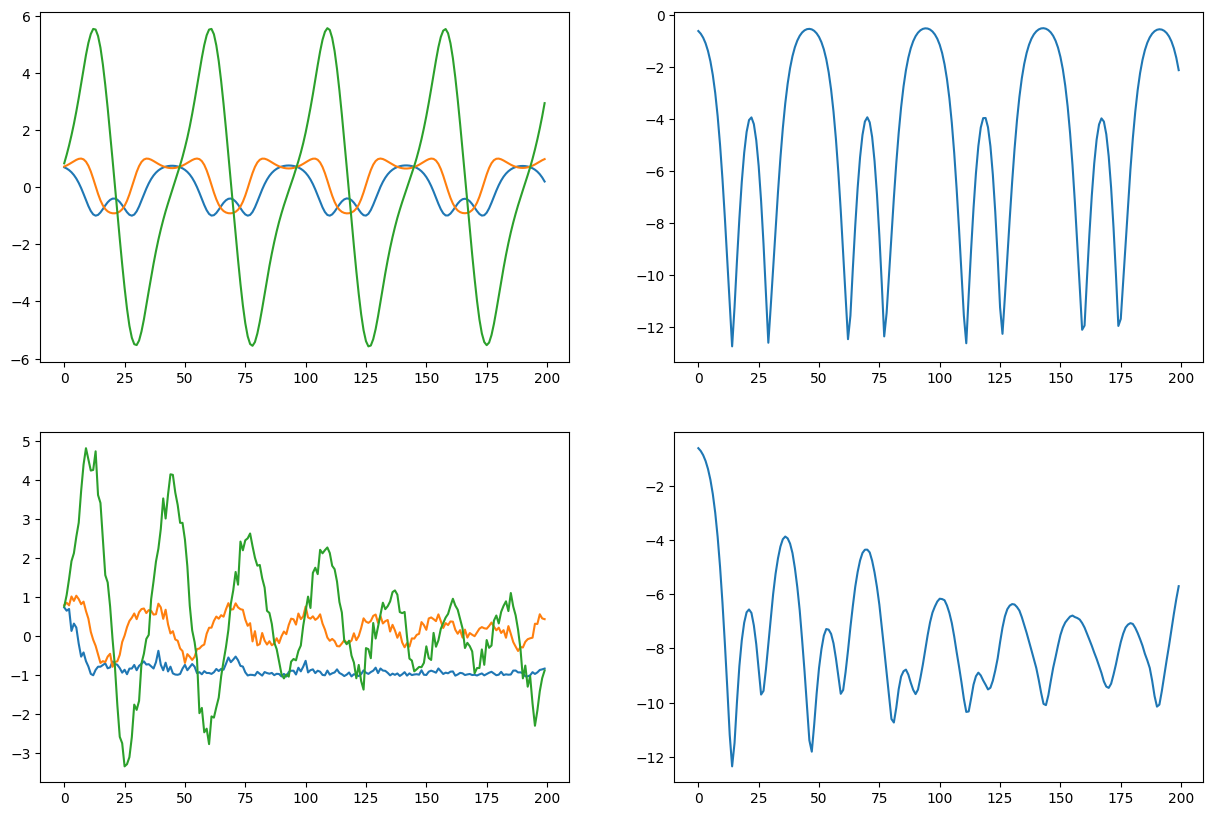

In [42]:

img_o = img_o.detach()
img_r = img_r.detach()
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(15, 10))
axs[0, 0].plot(o[0, start_i:length+start_i, 0].cpu())
axs[0, 0].plot(o[0, start_i:length+start_i, 1].cpu())
axs[0, 0].plot(o[0, start_i:length+start_i, 2].cpu())
axs[0, 1].plot(r[0, start_i:length+start_i, 0].cpu())

axs[1, 0].plot(img_o[0, :length, 0].cpu())
axs[1, 0].plot(img_o[0, :length, 1].cpu())
axs[1, 0].plot(img_o[0, :length, 2].cpu())
axs[1, 1].plot(img_r[0, :length, 0].cpu())

plt.show()

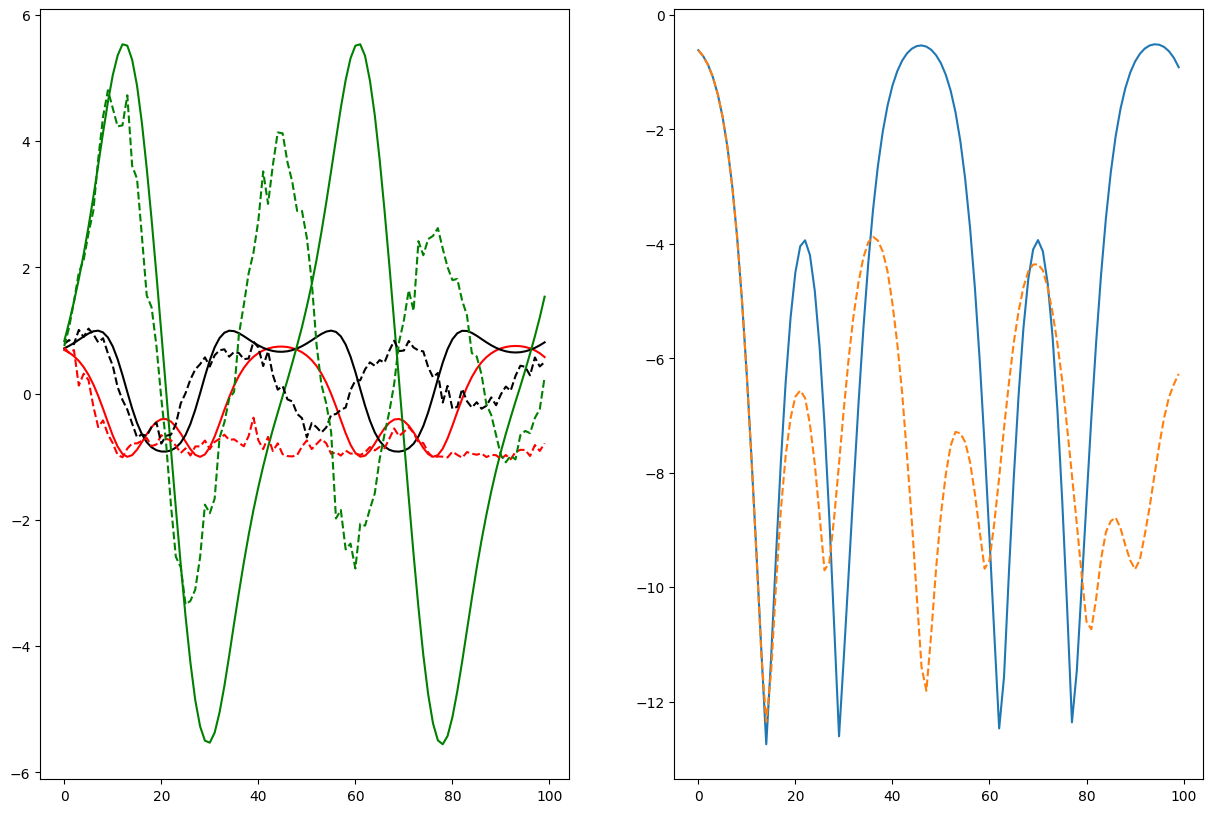

In [43]:
start_i=0
length=100

img_o = img_o.detach()
img_r = img_r.detach()
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 10))
axs[0].plot(o[0, start_i:length+start_i, 0].cpu(), color='red', linestyle='-')
axs[0].plot(o[0, start_i:length+start_i, 1].cpu(), color='black', linestyle='-')
axs[0].plot(o[0, start_i:length+start_i, 2].cpu(), color='green', linestyle='-')
axs[1].plot(r[0, start_i:length+start_i, 0].cpu())

axs[0].plot(img_o[0, :length, 0].cpu(), color='red', linestyle='--',)
axs[0].plot(img_o[0, :length, 1].cpu(), color='black', linestyle='--',)
axs[0].plot(img_o[0, :length, 2].cpu(), color='green', linestyle='--',)
axs[1].plot(img_r[0, :length, 0].cpu(), linestyle='--',)

plt.show()

In [44]:
reward, images = test_actor(actor, env, render=True)
print(reward)

tensor(-6791.8472)


In [45]:
from matplotlib import animation
from IPython.display import HTML
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

# Display first frame
im = ax.imshow(images[0])

# Animation update function
def update(frame):
    im.set_array(images[frame])
    return [im]

# Create animation
anim = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(images),
    interval=20,  # milliseconds between frames (50 FPS)
    blit=True
)

# Display in notebook
plt.close()  # Prevent static image from showing
HTML(anim.to_html5_video())

In [51]:
world_model.save('.')
trainer.save('.')